In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Which gender survived more?
# Which passenger class survived more?
# What was the average age of passengers?
# Which class paid the highest average fare?
# Did passengers with higher fares survive more often?
# Did passengers traveling alone survive more?
# Which embarkation point had the highest survival rate?
# What is the relationship between Age and Fare?
# Which numerical columns are most related to survival?
# Which features have the strongest positive and negative correlation with Survival?

In [3]:
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df.values

array([[892, 0, 3, ..., 7.8292, nan, 'Q'],
       [893, 1, 3, ..., 7.0, nan, 'S'],
       [894, 0, 2, ..., 9.6875, nan, 'Q'],
       ...,
       [1307, 0, 3, ..., 7.25, nan, 'S'],
       [1308, 0, 3, ..., 8.05, nan, 'S'],
       [1309, 0, 3, ..., 22.3583, nan, 'C']],
      shape=(418, 12), dtype=object)

In [8]:
df.index

RangeIndex(start=0, stop=418, step=1)

In [9]:
df.Name

0                                  Kelly, Mr. James
1                  Wilkes, Mrs. James (Ellen Needs)
2                         Myles, Mr. Thomas Francis
3                                  Wirz, Mr. Albert
4      Hirvonen, Mrs. Alexander (Helga E Lindqvist)
                           ...                     
413                              Spector, Mr. Woolf
414                    Oliva y Ocana, Dona. Fermina
415                    Saether, Mr. Simon Sivertsen
416                             Ware, Mr. Frederick
417                        Peter, Master. Michael J
Name: Name, Length: 418, dtype: object

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].mode()[0])

In [11]:
df["Fare"] = df["Fare"].fillna(df["Fare"].mode()[0])

In [12]:
df["Cabin"] = df["Cabin"].fillna(df["Cabin"].mode()[0])

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [14]:
# Which gender survived more?

gender_survival = df.groupby("Sex")["Survived"].sum()
print(gender_survival)

Sex
female    152
male        0
Name: Survived, dtype: int64


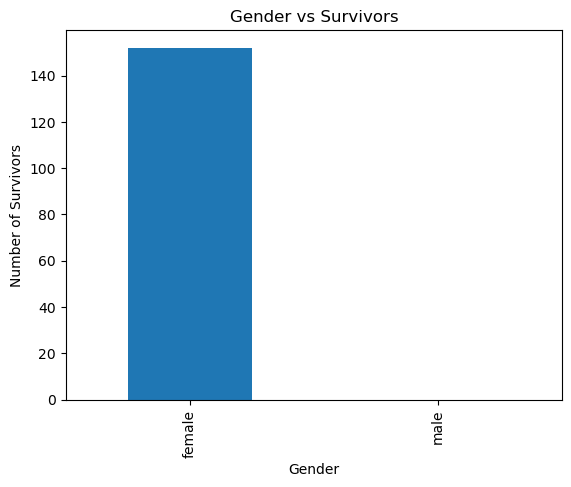

In [15]:


gender_survival.plot(kind="bar")
plt.title("Gender vs Survivors")
plt.xlabel("Gender")
plt.ylabel("Number of Survivors")
plt.show()

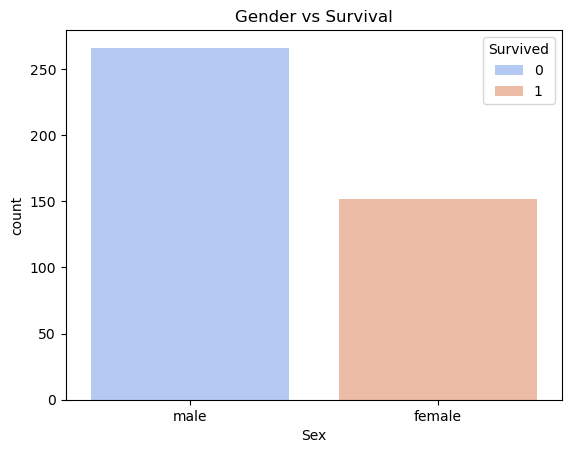

In [16]:


sns.countplot(data=df, x="Sex", hue="Survived", palette="coolwarm")
plt.title("Gender vs Survival")
plt.show()

In [17]:
# Which passenger class survived more?

passenger_class = df.groupby(["Pclass", "Survived"]).size()
print(passenger_class)

Pclass  Survived
1       0            57
        1            50
2       0            63
        1            30
3       0           146
        1            72
dtype: int64


In [18]:
# What was the average age of passengers?

average_age = df.groupby("Pclass")["Age"].mean()
print(average_age)

Pclass
1    39.242991
2    28.359355
3    23.027890
Name: Age, dtype: float64


In [19]:
# Which class paid the highest average fare?

average_fare = df.groupby("Pclass")["Fare"].mean()
print(average_fare)

Pclass
1    94.280297
2    22.202104
3    12.438074
Name: Fare, dtype: float64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13764\3517532367.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


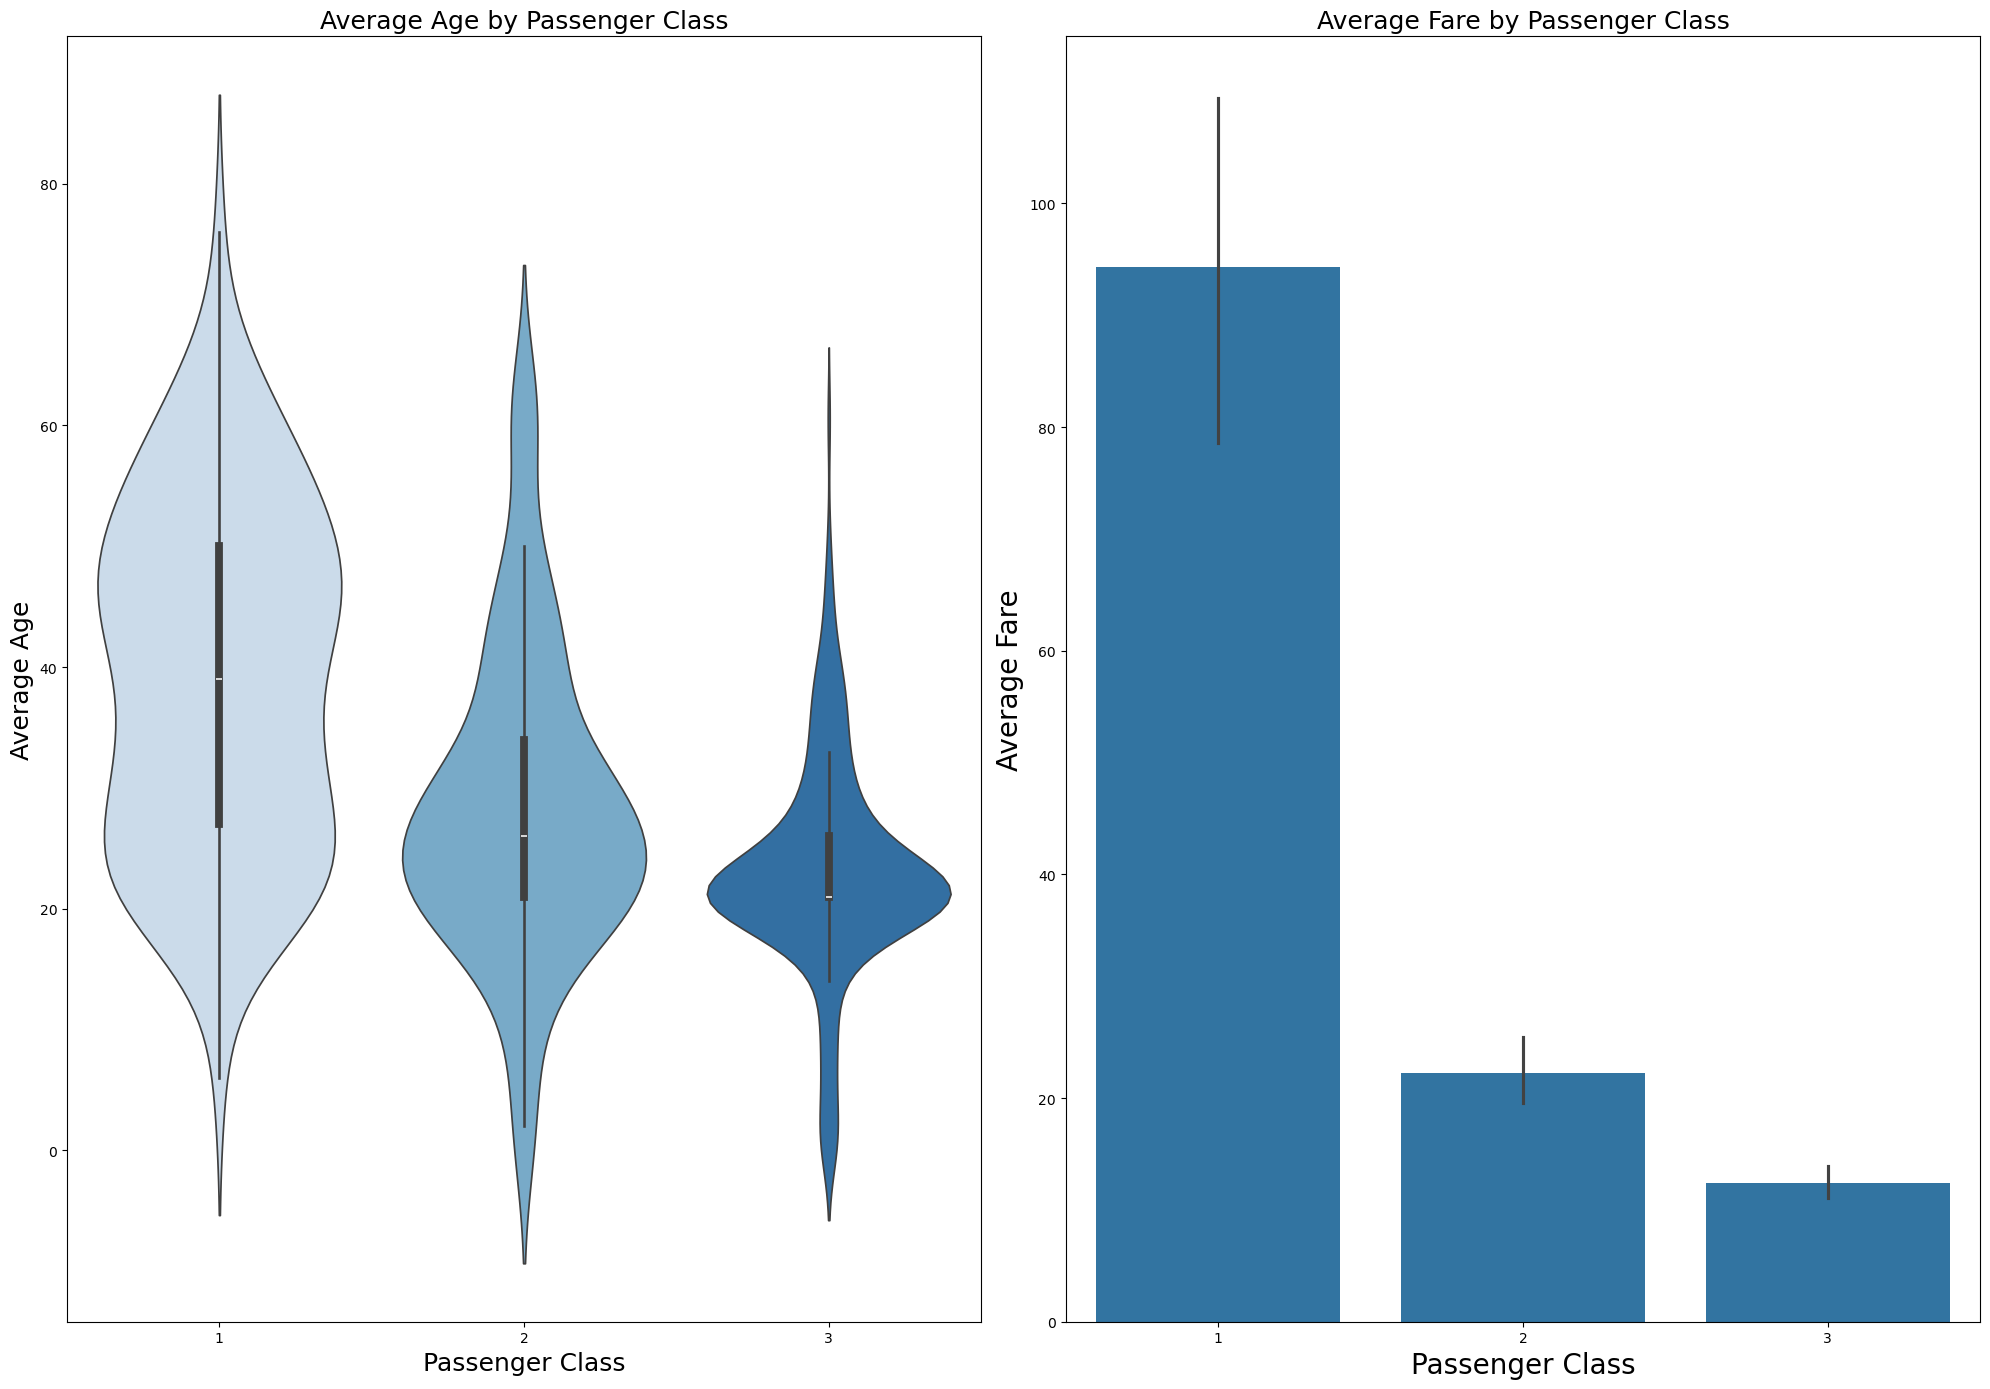

In [20]:
plt.figure(figsize=(20, 14))

# Average Age
plt.subplot(1, 2, 1)
sns.violinplot(
    data=df,
    x="Pclass",
    y="Age",
    palette="Blues"
)

plt.title("Average Age by Passenger Class",fontsize=18)
plt.xlabel("Passenger Class",fontsize=18)
plt.ylabel("Average Age",fontsize=18)

# Average Fare
plt.subplot(1, 2, 2)
sns.barplot(data=df, x="Pclass", y="Fare")

plt.title("Average Fare by Passenger Class",fontsize=18)
plt.xlabel("Passenger Class",fontsize=20)
plt.ylabel("Average Fare",fontsize=20)

plt.tight_layout()
plt.show()

In [21]:
# Did passengers with higher fares survive more often?

fare_survival = df.groupby("Survived")["Fare"].mean()
print(fare_survival)

Survived
0    27.453524
1    49.747699
Name: Fare, dtype: float64


In [22]:
# Did passengers traveling alone survive more?

df["Alone"] = (df["SibSp"] + df["Parch"] == 0)



In [23]:
alone_survival = df.groupby("Alone")["Survived"].mean()
print(alone_survival)

Alone
False    0.509091
True     0.268775
Name: Survived, dtype: float64


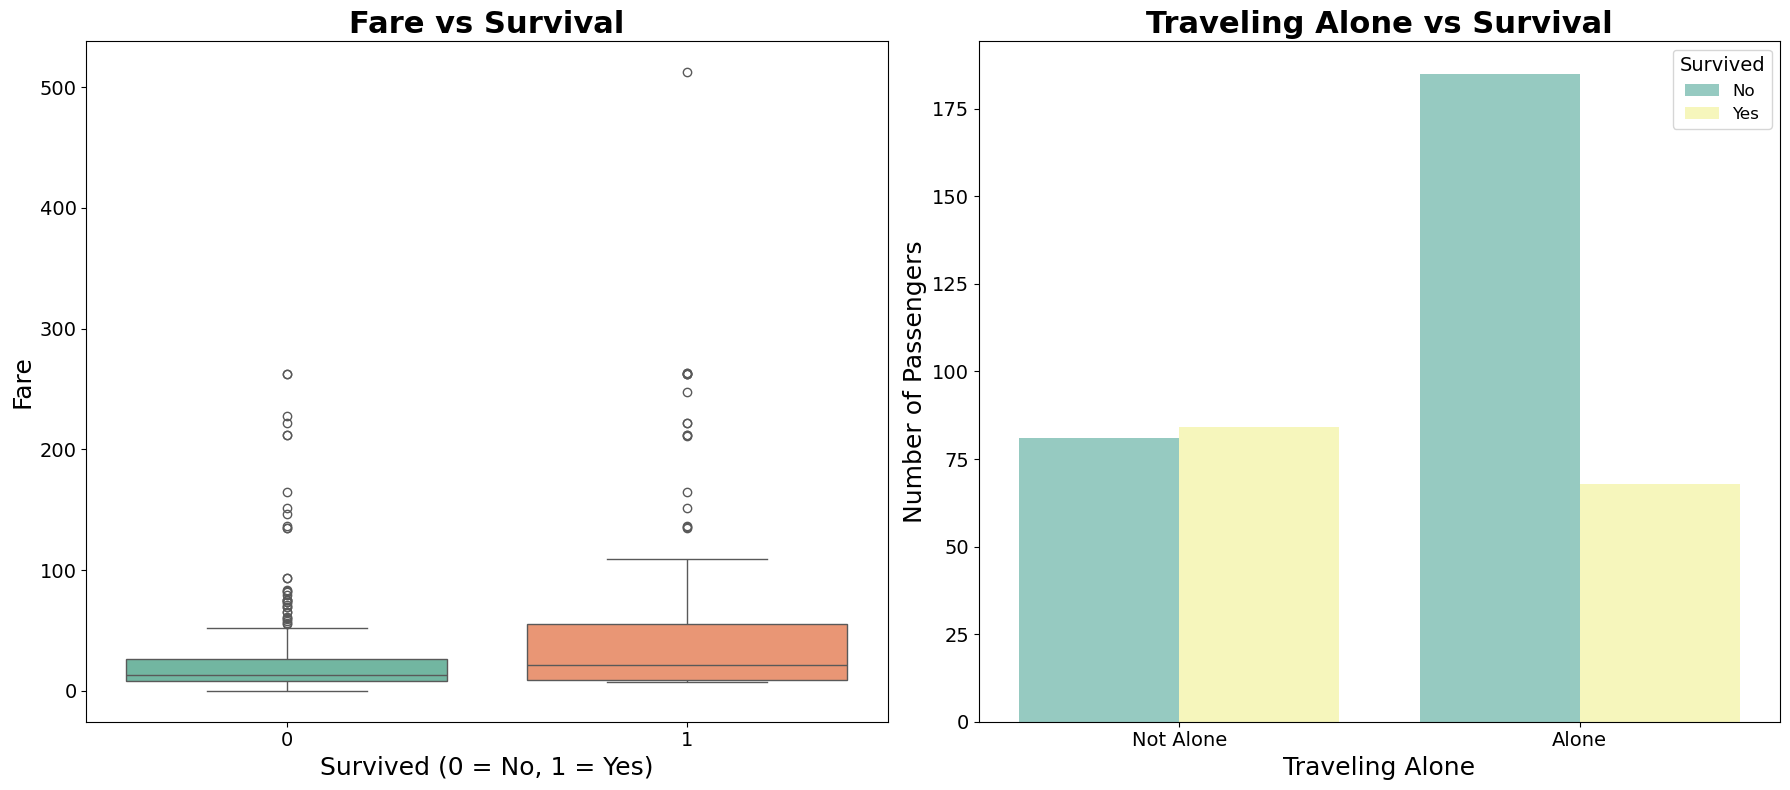

In [24]:

df["Alone"] = (df["SibSp"] + df["Parch"] == 0)


plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare",
    hue="Survived",
    palette="Set2",
    legend=False
)

plt.title("Fare vs Survival", fontsize=22, fontweight="bold")
plt.xlabel("Survived (0 = No, 1 = Yes)", fontsize=18)
plt.ylabel("Fare", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.subplot(1, 2, 2)

sns.countplot(
    data=df,
    x="Alone",
    hue="Survived",
    palette="Set3"
)

plt.title("Traveling Alone vs Survival", fontsize=22, fontweight="bold")
plt.xlabel("Traveling Alone", fontsize=18)
plt.ylabel("Number of Passengers", fontsize=18)
plt.xticks([0, 1], ["Not Alone", "Alone"], fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title="Survived", labels=["No", "Yes"], fontsize=12, title_fontsize=14)


plt.tight_layout()

plt.show()

In [25]:
# Which embarkation point had the highest survival rate?

embarked_survival = df.groupby("Embarked")["Survived"].mean()
print(embarked_survival)

Embarked
C    0.392157
Q    0.521739
S    0.325926
Name: Survived, dtype: float64


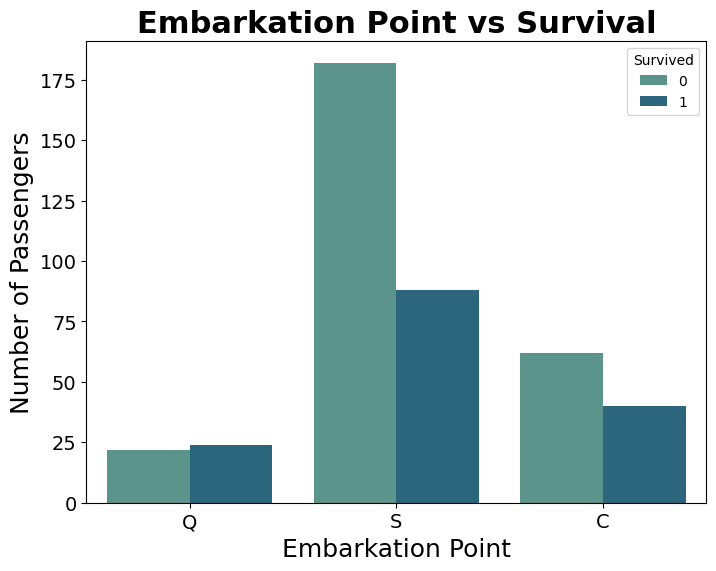

In [26]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="Embarked",
    hue="Survived",
    palette="crest"
)

plt.title("Embarkation Point vs Survival", fontsize=22, fontweight="bold")
plt.xlabel("Embarkation Point", fontsize=18)
plt.ylabel("Number of Passengers", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [27]:
# What is the relationship between Age and Fare?

relationship = df[["Age", "Fare"]].corr()
print(relationship)

           Age      Fare
Age   1.000000  0.363797
Fare  0.363797  1.000000


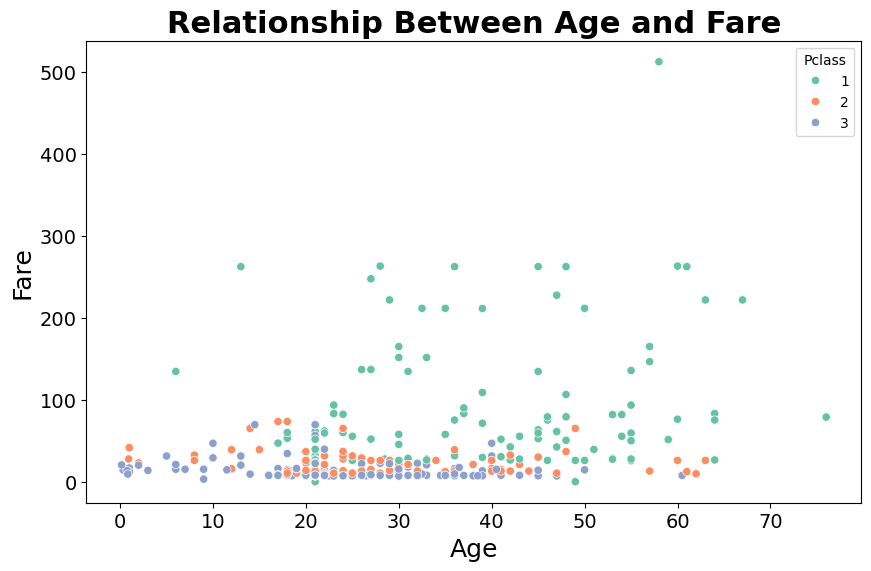

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Pclass",
    palette="Set2"
)

plt.title("Relationship Between Age and Fare", fontsize=22, fontweight="bold")
plt.xlabel("Age", fontsize=18)
plt.ylabel("Fare", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

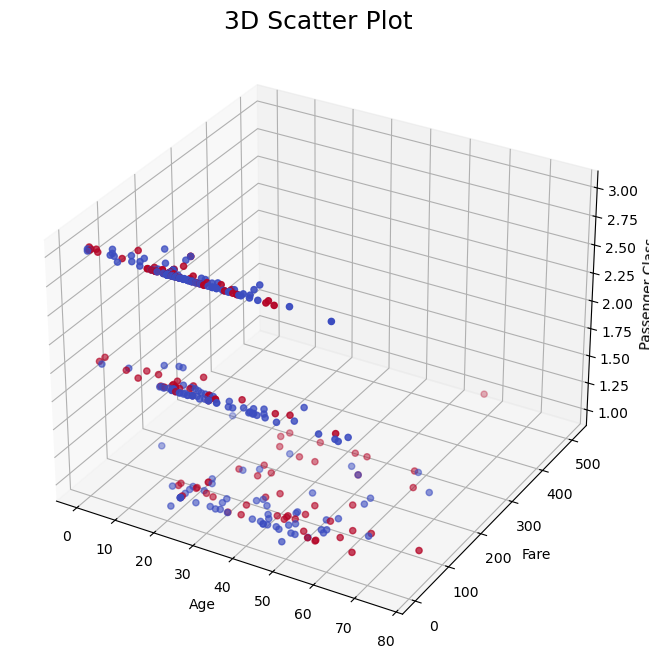

In [29]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["Age"],
    df["Fare"],
    df["Pclass"],
    c=df["Survived"],
    cmap="coolwarm"
)

ax.set_title("3D Scatter Plot", fontsize=18)
ax.set_xlabel("Age")
ax.set_ylabel("Fare")
ax.set_zlabel("Passenger Class")

plt.show()

In [30]:
# Which numerical columns are most related to survival?

correlation = df.corr(numeric_only=True)

survival_corr = correlation[["Survived"]]
print(survival_corr)

             Survived
PassengerId -0.023245
Survived     1.000000
Pclass      -0.108615
Age          0.021962
SibSp        0.099943
Parch        0.159120
Fare         0.192229
Alone       -0.244187


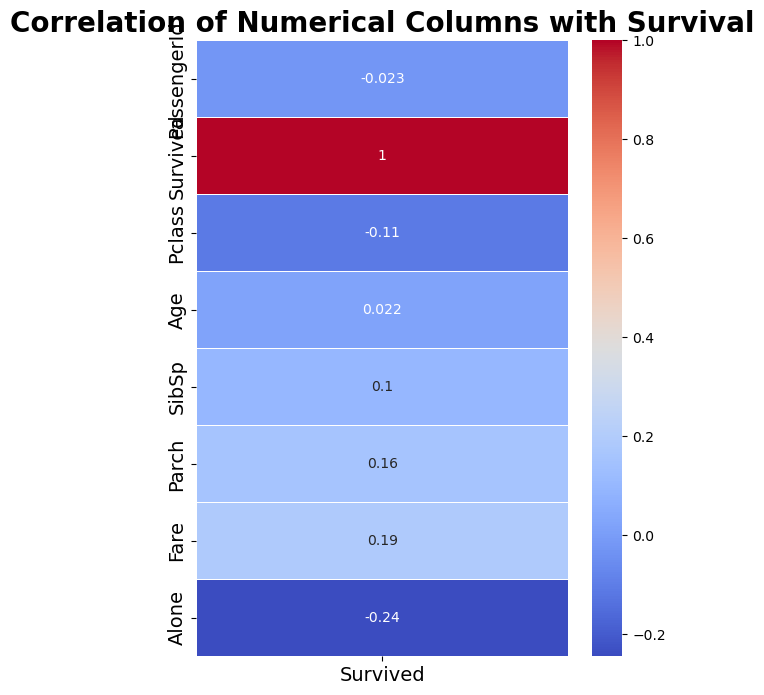

In [31]:
plt.figure(figsize=(6, 8))

sns.heatmap(
    survival_corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation of Numerical Columns with Survival",
          fontsize=20,
          fontweight="bold")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [32]:
# Which features have the strongest positive and negative correlation with Survival?

correlation = df.corr(numeric_only=True)

survival_corr = correlation["Survived"].sort_values()

print(survival_corr)

Alone         -0.244187
Pclass        -0.108615
PassengerId   -0.023245
Age            0.021962
SibSp          0.099943
Parch          0.159120
Fare           0.192229
Survived       1.000000
Name: Survived, dtype: float64


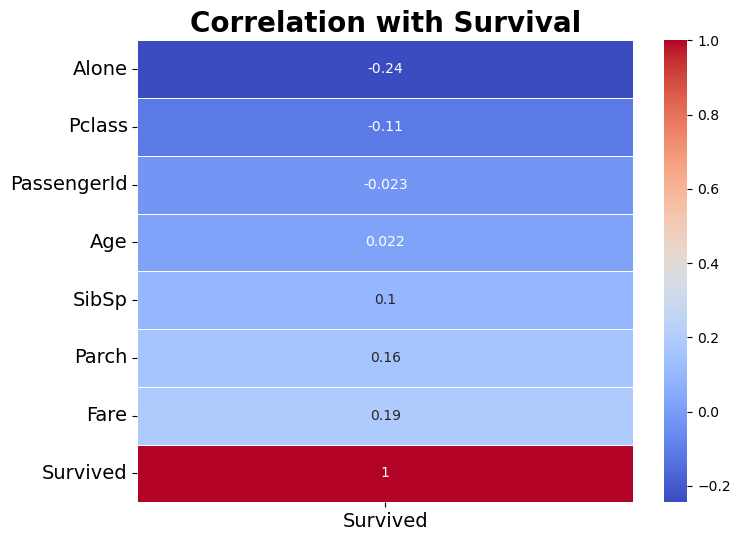

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    survival_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation with Survival", fontsize=20, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [34]:
df.to_csv("titanic_updated.csv", index=False)